### **BóSight: Behaviour Classification**
#### Trains a ResNet-50 to classify each cow crop into one of four behaviours —
#### lying, standing, feeding, moving — on a Kaggle T4 GPU.
#
#### Pipeline:
####   1. Auto-detect the crops and behaviour-label datasets under /kaggle/input
####   2. Label each crop by joining its filename timestamp to the behaviour CSV
####   3. Map MmCows behaviour codes to 4 classes (codes 0/5/6 excluded)
####   4. Handle class imbalance with a weighted sampler + class-weighted loss
####   5. Fine-tune ResNet-50, keep the best checkpoint by validation macro-F1
####   6. Evaluate on the held-out test split; save the model and metrics
#
#### **Results (test set):**
####   Accuracy 95.0%, macro-F1 0.807.
####   Per-class F1: lying 0.997, feeding 0.959, standing 0.933, moving 0.339
####   (moving is rare, ~1.5%, and temporal, so it is the hardest class).
#
#### Note: Attach two datasets — crops (`.../bosight_crops/{train,val,test}/<cow>/*.jpg`)
#### and behaviour labels (16 `C0n_0725.csv`) — set Accelerator to GPU T4, and enable
#### Internet (torchvision downloads pretrained ResNet-50). Dataset paths are auto-detected.

## 1. Setup

In [ ]:
# Standard scientific + PyTorch stack. Nothing exotic here.
import os, time, random, json, glob
from pathlib import Path
from collections import Counter

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True   # some crops are slightly truncated; don't crash on them
from tqdm import tqdm

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Fix every random seed so a re-run gives the same split/shuffle/init — important for
# a result you're going to quote in a report.
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE, '| torch', torch.__version__)
if DEVICE=='cpu':
    # Training ResNet-50 on CPU is painfully slow — this is really a "you forgot the GPU" nudge.
    print('WARNING: no GPU detected. Set Accelerator -> GPU T4 in the sidebar, then restart & run.')

## 2. Auto-find dataset paths

In [ ]:
# Kaggle mounts each attached dataset under /kaggle/input/<slug>/..., and the slug
# depends on what you named it. Rather than hard-code paths, we go hunting for the
# folders we need so the notebook works no matter what the datasets are called.

def find_dir(target_name, contains=None):
    '''Walk /kaggle/input for a folder literally named target_name
    (optionally one that also contains a given subfolder).'''
    for root, dirs, files in os.walk('/kaggle/input'):
        if os.path.basename(root) == target_name:
            if contains is None or (Path(root)/contains).exists():
                return Path(root)
    return None

# Crops: prefer a folder actually called 'bosight_crops' that has train/ inside it...
CROPS_DIR = find_dir('bosight_crops', contains='train')
if CROPS_DIR is None:
    # ...but if it was renamed, just grab whatever folder holds train/val/test.
    for root, dirs, files in os.walk('/kaggle/input'):
        if {'train','val','test'}.issubset(set(dirs)):
            CROPS_DIR = Path(root); break

# Behaviour labels: the folder that contains C01_0725.csv is the one we want.
BEH_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if any(f.startswith('C01_0725') and f.endswith('.csv') for f in files):
        BEH_DIR = Path(root); break

OUT_DIR = Path('/kaggle/working'); OUT_DIR.mkdir(exist_ok=True)   # where trained weights get saved
print('CROPS_DIR :', CROPS_DIR)
print('BEH_DIR   :', BEH_DIR)
# Fail loudly and early if either input is missing — better than a confusing error 40 lines down.
assert CROPS_DIR and BEH_DIR, 'Dataset not found - check that both inputs are attached.'
print('splits found:', sorted(os.listdir(CROPS_DIR)))
print('beh csvs    :', len(glob.glob(str(BEH_DIR/'C*_0725.csv'))))

## 3. Config

In [ ]:
# The four behaviours we predict, and how MmCows' raw codes map onto them.
CLASSES=['lying','standing','feeding','moving']
CLASS_TO_IDX={c:i for i,c in enumerate(CLASSES)}
# MmCows codes: 1=walking, 2=standing, 3/4=feeding (head up/down), 7=lying.
# Codes 0 (unknown), 5 (licking), 6 (drinking) are ambiguous, so we drop them entirely.
CODE_TO_CLASS={1:'moving',2:'standing',3:'feeding',4:'feeding',7:'lying'}

# Training hyper-parameters. 224 is the size ResNet expects; 15 epochs is plenty for
# fine-tuning; num_workers=4 keeps the GPU fed on Kaggle (0/2 sometimes stall there).
IMG_SIZE=224; BATCH=64; EPOCHS=15; LR=1e-4; NUM_WORKERS=4

## 4. Build labelled index (crop → timestamp → behaviour → 4-class)

In [ ]:
# Build a fast lookup of {timestamp: behaviour_code} per cow, so labelling a crop is
# just a dict get instead of scanning a CSV every time.
beh_lookup={}
for c in range(1,17):
    cow=f'C{c:02d}'
    df=pd.read_csv(BEH_DIR/f'{cow}_0725.csv')
    beh_lookup[cow]=dict(zip(df['timestamp'].astype(int), df['behavior'].astype(int)))
print('behaviour tables:', len(beh_lookup))

def build_index(split):
    '''Walk one split's crops and attach a label to each, giving one (path, label) row.
    The crop filename starts with the Unix timestamp, e.g. "1690289681_07-54-41_3.jpg",
    which we use to look up what the cow was doing at that moment.'''
    rows=[]
    sd=CROPS_DIR/split
    for cow in sorted(os.listdir(sd)):
        cd=sd/cow
        if not cd.is_dir(): continue
        for fn in os.listdir(cd):
            if not fn.lower().endswith(('.jpg','.jpeg','.png')): continue
            ts=int(fn.split('_')[0])                 # leading token = timestamp
            code=beh_lookup.get(cow,{}).get(ts)
            if code is None: continue                # no label for this second → skip
            cls=CODE_TO_CLASS.get(code)
            if cls is None: continue                 # excluded behaviour (0/5/6) → skip
            rows.append({'path':str(cd/fn),'cow':cow,'ts':ts,
                         'label':CLASS_TO_IDX[cls],'class':cls})
    return pd.DataFrame(rows)

# The train/val/test split is already baked into the crop folders (from tracking), so
# we just index each one — no risk of leaking the same frame across splits.
train_df=build_index('train'); val_df=build_index('val'); test_df=build_index('test')
print('train',len(train_df),'| val',len(val_df),'| test',len(test_df))

## 5. Class distribution

In [ ]:
# Quick look at how imbalanced the classes are. Spoiler: lying dominates and 'moving'
# is tiny (~1-2%), which is exactly why we bother with weighting/sampling below.
def dist(df,name):
    d=df['class'].value_counts().reindex(CLASSES).fillna(0).astype(int)
    print(f'{name:6s}:',dict(d)); return d
dtr=dist(train_df,'train'); dist(val_df,'val'); dist(test_df,'test')
plt.figure(figsize=(6,4))
plt.bar(dtr.index,dtr.values,color=['#4C72B0','#55A868','#C44E52','#8172B3'])
plt.title('Train class distribution'); plt.show()

## 6. Datasets & loaders (with imbalance handling)

In [ ]:
# ImageNet normalisation stats — required because we start from ImageNet-pretrained weights.
MEAN=[0.485,0.456,0.406]; STD=[0.229,0.224,0.225]
# Train-time augmentation (flip/rotate/jitter) to make the model a bit more robust;
# eval transform is clean (just resize + normalise) so metrics aren't randomised.
train_tf=transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(),transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2,0.2),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
eval_tf=transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),transforms.Normalize(MEAN,STD)])

class CowDS(Dataset):
    # Thin wrapper: given the index dataframe, load the image and hand back (tensor, label).
    def __init__(s,df,tf): s.df=df.reset_index(drop=True); s.tf=tf
    def __len__(s): return len(s.df)
    def __getitem__(s,i):
        r=s.df.iloc[i]; return s.tf(Image.open(r['path']).convert('RGB')), r['label']

train_ds=CowDS(train_df,train_tf); val_ds=CowDS(val_df,eval_tf); test_ds=CowDS(test_df,eval_tf)

# --- two-pronged imbalance handling ---
cc=train_df['label'].value_counts().reindex(range(len(CLASSES))).fillna(0).values
# 1) Weighted sampler: rare classes (esp. 'moving') get drawn more often per epoch.
sw=(1.0/np.clip(cc,1,None))[train_df['label'].values]
sampler=WeightedRandomSampler(torch.DoubleTensor(sw),len(sw),replacement=True)
# 2) Class-weighted loss: mistakes on rare classes are penalised harder.
ce_w=torch.tensor(cc.sum()/(len(CLASSES)*np.clip(cc,1,None)),dtype=torch.float32).to(DEVICE)

# Only the training loader uses the sampler; val/test stay in fixed order for honest metrics.
train_loader=DataLoader(train_ds,batch_size=BATCH,sampler=sampler,num_workers=NUM_WORKERS,pin_memory=True)
val_loader=DataLoader(val_ds,batch_size=BATCH,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)
test_loader=DataLoader(test_ds,batch_size=BATCH,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)
print('class counts:',cc.astype(int),'| CE weights:',ce_w.cpu().numpy().round(3))

## 7. Model — ResNet-50

In [ ]:
# Transfer learning: take ResNet-50 pretrained on ImageNet and swap its 1000-class head
# for our 4 classes. The pretrained backbone already knows edges/textures/shapes, so we
# only need to teach it what cow postures look like — much cheaper than training from scratch.
model=models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc=nn.Linear(model.fc.in_features,len(CLASSES)); model=model.to(DEVICE)
criterion=nn.CrossEntropyLoss(weight=ce_w)                 # class-weighted, from the cell above
optimizer=torch.optim.Adam(model.parameters(),lr=LR)
# Drop the learning rate when validation F1 stops improving, so late epochs can fine-tune.
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='max',factor=0.5,patience=2)
print('ready')

## 8. Train (saves best by macro-F1)

In [ ]:
def run_epoch(loader,train=True):
    '''One pass over a loader. Same code path for train and eval — the only differences
    are grad tracking and the optimiser step — so metrics are computed identically.'''
    model.train() if train else model.eval()
    losses,preds,gts=[],[],[]
    ctx=torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x,y in tqdm(loader,leave=False):
            x,y=x.to(DEVICE),y.to(DEVICE)
            if train: optimizer.zero_grad()
            out=model(x); loss=criterion(out,y)
            if train: loss.backward(); optimizer.step()
            losses.append(loss.item()); preds+=out.argmax(1).cpu().tolist(); gts+=y.cpu().tolist()
    # macro-F1 (not accuracy): averages all 4 classes equally, so the rare 'moving'
    # class actually counts — accuracy would happily ignore it.
    return np.mean(losses), f1_score(gts,preds,average='macro',zero_division=0)

# Keep the checkpoint from the best validation epoch, not the last one — late epochs
# overfit (train F1 → 0.99 while val F1 plateaus), so "last" would be a worse model.
best_f1,history=0.0,[]
for ep in range(1,EPOCHS+1):
    t0=time.time()
    trl,trf=run_epoch(train_loader,True); val,vaf=run_epoch(val_loader,False)
    scheduler.step(vaf)
    history.append(dict(epoch=ep,train_loss=trl,train_f1=trf,val_loss=val,val_f1=vaf))
    print(f'Epoch {ep:2d} | train {trl:.3f}/{trf:.3f} | val {val:.3f}/{vaf:.3f} | {time.time()-t0:.0f}s')
    if vaf>best_f1:
        best_f1=vaf; torch.save(model.state_dict(),OUT_DIR/'behaviour_best.pt')
        print(f'  saved best (val macro-F1 {best_f1:.3f})')
print('Best val macro-F1:',round(best_f1,4))

## 9. Curves & test evaluation

In [ ]:
# Training curves. The tell-tale sign to look for: train and val F1 diverging (train keeps
# climbing, val flattens) = mild overfitting, which is fine because we kept the best-val checkpoint.
h=pd.DataFrame(history)
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(h.epoch,h.train_loss,label='train');ax[0].plot(h.epoch,h.val_loss,label='val');ax[0].set_title('Loss');ax[0].legend()
ax[1].plot(h.epoch,h.train_f1,label='train');ax[1].plot(h.epoch,h.val_f1,label='val');ax[1].set_title('Macro-F1');ax[1].legend()
plt.tight_layout();plt.show()

In [ ]:
# Final honest evaluation on the held-out test set, using the BEST checkpoint (reloaded
# here in case the last epoch wasn't the best). Nothing here touches the optimiser.
model.load_state_dict(torch.load(OUT_DIR/'behaviour_best.pt',map_location=DEVICE)); model.eval()
preds,gts=[],[]
with torch.no_grad():
    for x,y in tqdm(test_loader):
        preds+=model(x.to(DEVICE)).argmax(1).cpu().tolist(); gts+=y.tolist()
# Per-class precision/recall/F1 — this is where you see 'moving' underperform vs the rest.
print(classification_report(gts,preds,target_names=CLASSES,digits=3,zero_division=0))
# Confusion matrix shows WHERE it confuses classes (e.g. standing↔feeding, moving→standing).
cm=confusion_matrix(gts,preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=CLASSES,yticklabels=CLASSES)
plt.xlabel('Predicted');plt.ylabel('True');plt.title('Test Confusion Matrix');plt.show()

## 10. Save artefacts to /kaggle/working (download after run)

In [ ]:
# Save the metrics alongside the weights so the report can quote exact numbers later
# without re-running training. (The .pt weights were already saved during training.)
rep=classification_report(gts,preds,target_names=CLASSES,output_dict=True,zero_division=0)
meta=dict(classes=CLASSES,best_val_macro_f1=best_f1,test_report=rep,
          n_train=len(train_df),n_val=len(val_df),n_test=len(test_df))
json.dump(meta,open(OUT_DIR/'behaviour_meta.json','w'),indent=2)
print('Saved behaviour_best.pt and behaviour_meta.json to /kaggle/working')
# REMINDER: /kaggle/working is wiped when the session ends. Download these now, or
# hit "Save Version", or the trained model is gone.
print('Download them from the Output tab, or Save Version to keep them.')

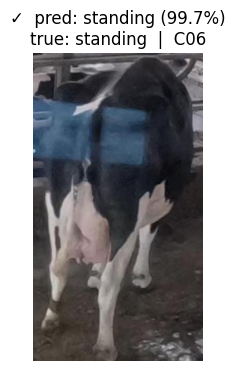

Full probabilities:
  standing :  99.7%
  moving   :   0.2%
  feeding  :   0.1%
  lying    :   0.0%


In [26]:
# ---- Single-image inference test ----
import random, torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()

# pick a random test crop (or set pick_path manually to a specific file)
row = test_df.sample(1, random_state=random.randint(0, 99999)).iloc[0]
pick_path = row['path']
true_class = row['class']

img = Image.open(pick_path).convert('RGB')
x = eval_tf(img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    probs = F.softmax(model(x), dim=1).cpu().numpy()[0]

pred_idx = int(probs.argmax())
pred_class = CLASSES[pred_idx]

# show image + prediction
plt.figure(figsize=(4, 4))
plt.imshow(img); plt.axis('off')
ok = "✓" if pred_class == true_class else "✗"
plt.title(f"{ok}  pred: {pred_class} ({probs[pred_idx]*100:.1f}%)\ntrue: {true_class}  |  {row['cow']}")
plt.show()

print("Full probabilities:")
for c, p in sorted(zip(CLASSES, probs), key=lambda t: -t[1]):
    print(f"  {c:9s}: {p*100:5.1f}%")